# Notebook 2 - Metode de Machine Learning și Deep Learning

În acest notebook aplicăm metodele de Machine Learning și Deep Learning cerute:

| Cerință | Metodă | Scop |
|---|---|---|
| **ML #1** | RandomForest Regression (Spark MLlib) | Predicția numărului de zboruri per oră per aeroport |
| **ML #2** | KMeans Clustering (Spark MLlib) | Gruparea aeroporturilor după profilul de trafic |
| **DL** | LSTM (TensorFlow/Keras) | Predicție time-series pe seria temporală a traficului |

**Date de intrare:** tabelul agregat `hourly_traffic.csv` produs de Notebook 1, care conține pentru fiecare combinație aeroport + oră + dată: numărul de zboruri înregistrate și o serie de feature-uri derivate fără data leakage.

<a id="3-metode-ml"></a>
## 3. Metode ML (Machine Learning)
<a id="31-initializarea-spark-ml"></a>
### 3.1. Inițializare SparkSession și încărcare date

Pornim o sesiune Spark în mod local și încărcăm tabelul agregat produs de Notebook 1. Setăm explicit variabilele de mediu pentru Python ca să evităm conflicte de versiuni între driver și worker pe Windows.

In [1]:
import os
import sys

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count

spark = SparkSession.builder \
    .appName('AirTrafficML') \
    .master('local[*]') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')

Spark version: 3.5.3


Încărcăm tabelul agregat `hourly_traffic.csv` generat în Notebook 1. Acesta conține câte zboruri au fost înregistrate per aeroport, per oră și per dată, împreună cu feature-urile derivate: traficul din ziua precedentă, media ultimelor 7 zile, numărul de rute și companii unice, volatilitatea traficului și reprezentările circulare ale orei.

In [2]:
# tabelul agregat produs de Notebook 1
df_hourly = spark.read.csv(
    os.path.join('..', 'data', 'hourly_traffic.csv'),
    header=True,
    inferSchema=True
)

print(f'Inregistrari incarcate: {df_hourly.count()}')
df_hourly.printSchema()
df_hourly.show(2)

Inregistrari incarcate: 10851
root
 |-- airport: string (nullable = true)
 |-- arrival_hour: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- flights_count: integer (nullable = true)
 |-- flights_yesterday: integer (nullable = true)
 |-- media_7zile: double (nullable = true)
 |-- quarter: integer (nullable = true)
 |-- nr_rute_unice: integer (nullable = true)
 |-- nr_companii: integer (nullable = true)
 |-- hour_sin: double (nullable = true)
 |-- hour_cos: double (nullable = true)
 |-- volatilitate_7zile: double (nullable = true)

+-------+------------+----------+-----------+----------+-------------+-----------------+-----------+-------+-------------+-----------+------------------+------------------+------------------+
|airport|arrival_hour|      date|day_of_week|is_weekend|flights_count|flights_yesterday|media_7zile|quarter|nr_rute_unice|nr_companii|          hour_sin|          hour_

---
### 3.2 ML 1 RandomForest Regression

#### 3.2.1 Enunțul problemei

Dorim să prezicăm **numărul de zboruri** (`flights_count`) care vor fi înregistrate la un aeroport într-o anumită oră a zilei. Modelul trebuie să învețe pattern-urile istorice de trafic și să generalizeze pentru ore viitoare nevăzute în antrenare.

#### 3.2.2 Justificarea alegerii metodei

**RandomForest Regression** este potrivit pentru această problemă din mai multe motive:
- Traficul aerian are relații **non-liniare** cu ora din zi — vârfuri dimineața (6-9) și seara (16-20), nu o creștere uniformă
- Este robust la date cu zgomot și nu necesită ca toate feature-urile să fie pe aceeași scală
- Oferă **importanța feature-urilor**, utilă pentru interpretarea și validarea modelului
- Rezistă la overfitting prin agregarea predicțiilor mai multor arbori de decizie independenți

#### 3.2.3 Explicarea soluției și a feature-urilor

Modelul primește ca input următoarele feature-uri, toate calculate **fără data leakage** (folosind doar informații disponibile la momentul predicției):

| Feature | Descriere | Justificare |
|---|---|---|
| `airport_idx` | Codul aeroportului (indexat numeric) | Fiecare aeroport are un volum de bază diferit |
| `arrival_hour` | Ora din zi (0-23) | Pattern-ul orar principal |
| `hour_sin`, `hour_cos` | Reprezentare circulară a orei | Ora 23 și ora 0 sunt adiacente — sin/cos captează asta |
| `day_of_week` | Ziua săptămânii (0=Luni) | Pattern-urile diferă între zilele lucrătoare |
| `is_weekend` | 1 dacă sâmbătă/duminică | Weekend are trafic diferit față de weekday |
| `flights_yesterday` | Traficul de ieri la aceeași oră | `lag(1)` — folosește doar date din trecut |
| `media_7zile` | Media ultimelor 7 zile la aceeași oră | `rowsBetween(-7, -1)` — fără data leakage |
| `volatilitate_7zile` | Abaterea standard a ultimelor 7 zile | Indică cât de predictibil este traficul la acea oră |
| `nr_rute_unice` | Numărul de rute unice de ieri | Calculat din ziua precedentă — fără data leakage |
| `nr_companii` | Numărul de companii aeriene de ieri | Calculat din ziua precedentă — fără data leakage |
| `quarter` | Trimestrul anului | Captează sezonalitate pe termen lung |

#### 3.2.4 Pregătirea datelor pentru ML

Eliminăm înregistrările cu valori lipsă în coloanele folosite ca feature-uri. Primele zile din dataset nu au `flights_yesterday` sau `media_7zile` (nu există date anterioare pentru ele), deci sunt excluse automat.

In [3]:
df_ml = df_hourly \
    .dropna(subset=['airport', 'arrival_hour', 'day_of_week',
                    'is_weekend', 'flights_count',
                    'flights_yesterday', 'media_7zile','volatilitate_7zile', 
                    'nr_rute_unice', 'nr_companii', 'quarter'])

print(f'Inregistrari pentru ML: {df_ml.count()}')
df_ml.select('airport', 'arrival_hour', 'flights_count',
             'flights_yesterday', 'media_7zile', 'volatilitate_7zile', 
             'nr_rute_unice', 'nr_companii', 'quarter').show(10)

Inregistrari pentru ML: 10731
+-------+------------+-------------+-----------------+-----------+------------------+-------------+-----------+-------+
|airport|arrival_hour|flights_count|flights_yesterday|media_7zile|volatilitate_7zile|nr_rute_unice|nr_companii|quarter|
+-------+------------+-------------+-----------------+-----------+------------------+-------------+-----------+-------+
|   EDDF|           0|            5|                4|        4.0|               0.0|            1|          2|      2|
|   EDDF|           1|            2|                3|        3.0|               0.0|            1|          3|      2|
|   EDDF|           2|            5|                4|        4.0|               0.0|            1|          4|      2|
|   EDDF|           3|           11|               17|       17.0|               0.0|           12|         11|      2|
|   EDDF|           4|           12|               12|       12.0|               0.0|           12|          8|      2|
|   EDDF| 

#### 3.2.5 Construirea Pipeline-ului ML

Folosim un **Pipeline Spark MLlib** care automatizează toți pașii de preprocesare și modelare într-un singur obiect reutilizabil.
Pipeline-ul conține 4 etape în ordine:
1. **StringIndexer** — transformă numele aeroportului (șir de caractere) în index numeric, necesar pentru algoritmii ML care lucrează cu valori numerice
2. **VectorAssembler** — combină toate feature-urile individuale într-un singur vector dens, formatul cerut de Spark MLlib
3. **StandardScaler** — normalizează fiecare feature la medie 0 și deviație standard 1, pentru stabilitate numerică
4. **RandomForestRegressor** — modelul de regresie propriu-zis

In [4]:
# Cerinta 4: Data Pipeline
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.regression import RandomForestRegressor

# Pas 1: StringIndexer — transforma numele aeroportului in index numeric
indexer = StringIndexer(
    inputCol='airport',
    outputCol='airport_idx',
    handleInvalid='keep'
)

# Pas 2: VectorAssembler — combina toate feature-urile intr-un vector
assembler = VectorAssembler(
    inputCols=[
        'airport_idx',
        'arrival_hour',
        'hour_sin',
        'hour_cos',
        'day_of_week',
        'is_weekend',
        'quarter',
        'flights_yesterday',
        'media_7zile',
        'volatilitate_7zile', 
        'nr_rute_unice',
        'nr_companii'
    ],
    outputCol='features_raw'
)

# Pas 3: StandardScaler — normalizeaza valorile
scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True,
    withStd=True
)

# Pas 4: RandomForestRegressor — modelul
rf = RandomForestRegressor(
    labelCol='flights_count',
    featuresCol='features',
    seed=42
)

# Pipeline
pipeline = Pipeline(stages=[indexer, assembler, scaler, rf])

print('Pipeline creat: StringIndexer → VectorAssembler → StandardScaler → RandomForest')

Pipeline creat: StringIndexer → VectorAssembler → StandardScaler → RandomForest


#### 3.2.6 Split cronologic și Hyperparameter Tuning

Pentru date de tip time-series, **split-ul aleator este incorect** deoarece modelul ar putea vedea date din viitor în antrenare. Folosim un **split cronologic**: antrenăm pe primele 80% din zile (cele mai vechi) și testăm pe ultimele 20% (cele mai recente). Astfel simulăm un scenariu realist în care modelul prezice zile pe care nu le-a văzut niciodată.

**Optimizarea hiperparametrilor** (Cerința 5) se face prin `CrossValidator` cu `ParamGridBuilder`. Testăm combinații de:
- `numTrees` — numărul de arbori din pădure
- `maxDepth` — adâncimea maximă a fiecărui arbore
- `minInstancesPerNode` — numărul minim de exemple per nod frunză (regularizare)

`CrossValidator` antrenează câte un model pentru fiecare combinație pe 3 fold-uri de validare încrucișată și alege automat combinația cu cel mai mic RMSE.

In [5]:
# Cerinta 5: Hyperparameter Tuning 
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator

# Split cronologic - antrenam pe trecut, testam pe viitor
dates = [r.date for r in df_ml.select('date').distinct().orderBy('date').collect()]
split_date = dates[int(len(dates) * 0.8)]

train_df = df_ml.filter(col('date') < split_date)
test_df  = df_ml.filter(col('date') >= split_date)

print(f'Split cronologic la data: {split_date}')
print(f'Train: {train_df.count()} randuri | Test: {test_df.count()} randuri')
print(f'Train acoperă: {dates[0]} → {split_date}')
print(f'Test acoperă:  {split_date} → {dates[-1]}')

paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [100]) \
    .addGrid(rf.maxDepth, [10, 12]) \
    .addGrid(rf.minInstancesPerNode, [5, 10]) \
    .build()

evaluator = RegressionEvaluator(labelCol='flights_count', predictionCol='prediction', metricName='rmse')

cv = CrossValidator(estimator=pipeline, estimatorParamMaps=paramGrid,
                    evaluator=evaluator, numFolds=3, seed=42)

print('Incep antrenarea (4 combinatii x 3 folduri = 12 modele)...')
cv_model = cv.fit(train_df)
print('Antrenare finalizata!')

Split cronologic la data: 2026-06-17
Train: 8558 randuri | Test: 2173 randuri
Train acoperă: 2026-04-05 → 2026-06-17
Test acoperă:  2026-06-17 → 2026-07-05
Incep antrenarea (4 combinatii x 3 folduri = 12 modele)...
Antrenare finalizata!


#### 3.2.7 Aplicarea și evaluarea modelului

Aplicăm modelul pe setul de test (date din ultimele 20% zile, nevăzute în antrenare) și calculăm trei metrici de evaluare:
- **RMSE** (Root Mean Squared Error) — penalizează mai mult erorile mari
- **MAE** (Mean Absolute Error) 
- **R²** — coeficientul de determinare, indică ce procent din variația datelor este explicat de model (1.0 = perfect)

Afișăm și predicțiile concrete pentru aeroportul București (LROP) pentru a verifica calitativ comportamentul modelului.

In [6]:
# Evaluarea modelului 
from pyspark.sql import functions as F
from pyspark.sql.functions import round as spark_round
predictions = cv_model.transform(test_df)

rmse = evaluator.evaluate(predictions)
mae  = RegressionEvaluator(
    labelCol='flights_count', predictionCol='prediction', metricName='mae'
).evaluate(predictions)
r2   = RegressionEvaluator(
    labelCol='flights_count', predictionCol='prediction', metricName='r2'
).evaluate(predictions)

print(f'\n=== Rezultate===')
print(f'  RMSE: {rmse:.2f} zboruri')
print(f'  MAE:  {mae:.2f} zboruri')
print(f'  R2:   {r2:.4f}')

# Cei mai buni hiperparametri
best_rf = cv_model.bestModel.stages[-1]
print(f'\n  Cei mai buni hiperparametri:')
print(f'  numTrees: {best_rf.getNumTrees}')
print(f'  maxDepth: {best_rf.getOrDefault("maxDepth")}')

print('\n  Exemple predictii vs valori reale:')
predictions.select('airport', 'arrival_hour', 'day_of_week',
                   'flights_count', 'prediction') \
           .show(30)

# Predictii pentru LROP (Bucuresti)
print('\n=== Predictii LROP (Bucuresti) - profil orar complet ===')
predictions.filter(col('airport') == 'LROP') \
           .select('airport', 'arrival_hour', 'day_of_week',
                   'flights_count', 'prediction') \
           .withColumn('prediction', spark_round(col('prediction'), 1)) \
           .orderBy('day_of_week', 'arrival_hour') \
           .show(30)

print('\n=== Corelatia predictie-realitate per aeroport ===')
predictions.groupBy('airport').agg(
    F.expr('corr(flights_count, prediction)').alias('corr_approx')
).show()


=== Rezultate===
  RMSE: 8.13 zboruri
  MAE:  4.40 zboruri
  R2:   0.8404

  Cei mai buni hiperparametri:
  numTrees: 100
  maxDepth: 12

  Exemple predictii vs valori reale:
+-------+------------+-----------+-------------+------------------+
|airport|arrival_hour|day_of_week|flights_count|        prediction|
+-------+------------+-----------+-------------+------------------+
|   EDDF|           0|          2|            4| 5.454813431274328|
|   EDDF|           1|          2|            3| 2.448647598609407|
|   EDDF|           2|          2|            1|2.0292811483408726|
|   EDDF|           3|          2|           16|14.339686175061656|
|   EDDF|           4|          2|           20|18.163882483991305|
|   EDDF|           5|          2|           21|21.097416511535794|
|   EDDF|           6|          2|           26|26.751504209020478|
|   EDDF|           7|          2|           40|  36.7678942464307|
|   EDDF|           8|          2|           27| 27.27446908288895|
|   EDDF

#### 3.2.8 Importanța feature-urilor și salvarea modelului

RandomForest oferă o măsură a importanței fiecărui feature — cât de mult contribuie la reducerea erorii de predicție. Această analiză validează că feature-urile alese sunt relevante și că modelul a învățat pattern-uri logice:
- `media_7zile` și `flights_yesterday` cu importanță mare confirmă că **traficul recent este cel mai bun predictor** al traficului viitor
- `nr_companii` și `nr_rute_unice` cu importanță semnificativă confirmă că **diversitatea operatorilor** indică volumul de trafic
- `hour_sin` mai importante decât `arrival_hour` brut confirmă că **reprezentarea circulară a orei** este superioară


In [7]:
import pandas as pd

feature_names = [
    'airport_idx',
    'arrival_hour',
    'hour_sin',
    'hour_cos',
    'day_of_week',
    'is_weekend',
    'quarter',
    'flights_yesterday',
    'media_7zile',
    'volatilitate_7zile', 
    'nr_rute_unice',
    'nr_companii'
]
feature_importances = best_rf.featureImportances.toArray()

fi_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print('\n=== Importanta Feature-urilor ===')
print(fi_df.to_string(index=False))

model_path = os.path.abspath(os.path.join('..', 'models', 'rf_model'))
os.makedirs(os.path.dirname(model_path), exist_ok=True)
model_path_spark = model_path.replace('\\', '/')
cv_model.bestModel.write().overwrite().save(model_path_spark)
print(f'\nModel salvat in: {model_path_spark}')


=== Importanta Feature-urilor ===
           feature  importance
       media_7zile    0.398688
 flights_yesterday    0.237003
       nr_companii    0.134487
     nr_rute_unice    0.080477
          hour_sin    0.052034
      arrival_hour    0.034870
volatilitate_7zile    0.028740
          hour_cos    0.015550
       airport_idx    0.010931
       day_of_week    0.005270
        is_weekend    0.001950
           quarter    0.000000

Model salvat in: D:/Facultate/master/an1/sem2/Big Data/project/models/rf_model


---
### 3.3 ML 2 KMeans Clustering

#### 3.3.1 Enunțul problemei

Dorim să **grupăm cele 5 aeroporturi** monitorizate după profilul lor de trafic, fără a folosi etichete predefinite. Scopul este să descoperim dacă există tipare naturale - de exemplu hub-uri mari cu trafic intens și variabil față de aeroporturi regionale cu volum redus și mai stabil.

#### 3.3.2 Justificarea alegerii metodei

**KMeans Clustering** este potrivit deoarece:
- Nu avem etichete predefinite pentru tipul aeroportului - KMeans le descoperă din date
- Fiecare aeroport poate fi caracterizat prin câteva metrici agreggate (trafic maxim, medie, variabilitate)
- KMeans este eficient și rezultatele sunt ușor interpretabile prin analiza centroizilor
- Numărul mic de aeroporturi (5) face metoda foarte tractabilă

#### 3.3.3 Explicarea soluției

Caracterizăm fiecare aeroport prin două dimensiuni:
- **`max_traffic`** - traficul maxim înregistrat (indică capacitatea de vârf)
- **`coef_variatie`** - coeficientul de variație = deviație standard / medie (indică cât de impredictibil este traficul)

Aplicăm KMeans cu k=3 clustere pe aceste două dimensiuni după standardizare.

#### 3.3.4 Calculul profilului per aeroport

Agregăm toate înregistrările per aeroport pentru a obține metricile de profil. Coeficientul de variație (deviație standard / medie) este o măsură normalizată a variabilității — un aeroport cu coef_variatie mare are trafic impredictibil, iar unul cu valoare mică are trafic regulat și ușor de anticipat.

In [8]:
from pyspark.sql.functions import max, min, stddev, expr, when

df_profile = df_hourly.groupBy('airport') \
    .agg(
        max('flights_count').alias('max_traffic'),
        avg('flights_count').alias('avg_traffic'),
        (stddev('flights_count') / avg('flights_count')).alias('coef_variatie')
    ).fillna(0)

print('Profil per aeroport:')
df_profile.orderBy('avg_traffic', ascending=False).show()

Profil per aeroport:
+-------+-----------+------------------+------------------+
|airport|max_traffic|       avg_traffic|     coef_variatie|
+-------+-----------+------------------+------------------+
|   EGLL|         93|33.795936794582396|0.5898526829815255|
|   LFPG|         86| 32.18018018018018|0.5772876136867164|
|   EHAM|        103|30.254848894903024| 0.747233450845668|
|   EDDF|         79| 26.75729927007299|0.6506415478609282|
|   LROP|         26|  8.52217239661186|0.5513421442229648|
+-------+-----------+------------------+------------------+



#### 3.3.5 Alegerea numărului optim de clustere

Înainte de a aplica KMeans cu un k fix, folosim **Metoda Cotului (Elbow Method)** pentru a determina numărul optim de clustere. Antrenăm KMeans pentru k de la 2 la 8 și vizualizăm costul (Within Set Sum of Squared Errors). Punctul unde costul începe să scadă mai lent (cotul graficului) indică k-ul optim.

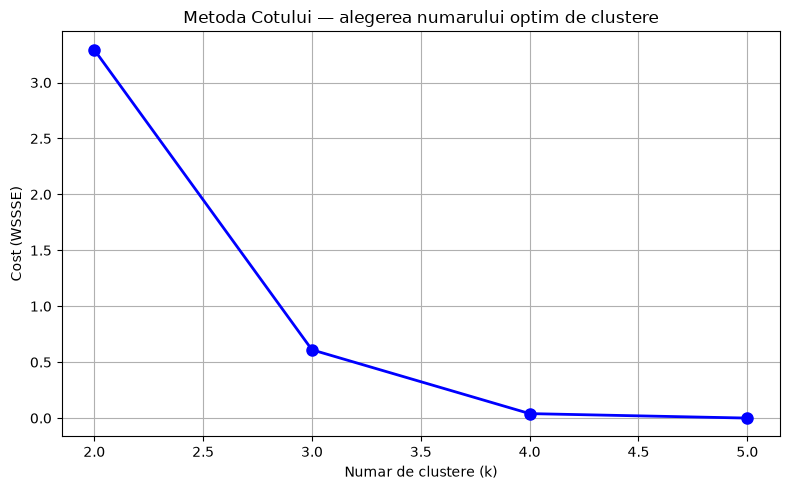

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler

# vectorul de features pentru KMeans
assembler_km = VectorAssembler(
    inputCols=['max_traffic', 'coef_variatie'], 
    outputCol='features_vec'
)
df_vec = assembler_km.transform(df_profile)

scaler_km = StandardScaler(inputCol='features_vec', outputCol='features', withStd=True, withMean=True)
df_scaled = scaler_km.fit(df_vec).transform(df_vec)

# Metoda Cotului
costs = []
k_range = range(2, 6)

for k in k_range:
    km = KMeans(k=k, featuresCol='features', seed=42)
    model_k = km.fit(df_scaled)
    costs.append(model_k.summary.trainingCost)

plt.figure(figsize=(8, 5))
plt.plot(k_range, costs, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Numar de clustere (k)')
plt.ylabel('Cost (WSSSE)')
plt.title('Metoda Cotului — alegerea numarului optim de clustere')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 3.3.6 Antrenarea KMeans cu k=3

Pe baza metodei cotului, alegem k=3 clustere. Antrenăm modelul KMeans pe profilul standardizat al aeroporturilor și afișăm apartenența fiecărui aeroport la un cluster, împreună cu interpretarea fiecărui grup.

In [10]:
# KMeans cu k=3
kmeans = KMeans(k=3, featuresCol='features', predictionCol='cluster', seed=42)
km_model = kmeans.fit(df_scaled)

df_clustered = km_model.transform(df_scaled).select('airport', 'cluster')

print('=== Rezultate KMeans Clustering ===')
df_clustered.show()

# Interpretarea clusterelor
print('=== Interpretarea clusterelor ===')
df_clustered.select('airport', 'cluster') \
            .withColumn('tip_aeroport',
                when(col('cluster') == 0, 'Hub Major - trafic intens continuu')
               .when(col('cluster') == 1, 'Aeroport Regional - varfuri clare')
               .otherwise('Hub Major - trafic fluctuant')) \
            .show(truncate=False)

=== Rezultate KMeans Clustering ===
+-------+-------+
|airport|cluster|
+-------+-------+
|   LFPG|      0|
|   EGLL|      0|
|   EDDF|      0|
|   EHAM|      2|
|   LROP|      1|
+-------+-------+

=== Interpretarea clusterelor ===
+-------+-------+----------------------------------+
|airport|cluster|tip_aeroport                      |
+-------+-------+----------------------------------+
|LFPG   |0      |Hub Major - trafic intens continuu|
|EGLL   |0      |Hub Major - trafic intens continuu|
|EDDF   |0      |Hub Major - trafic intens continuu|
|EHAM   |2      |Hub Major - trafic fluctuant      |
|LROP   |1      |Aeroport Regional - varfuri clare |
+-------+-------+----------------------------------+



#### 3.3.7 Evaluarea KMeans și validarea clusterelor

Evaluăm calitatea clusterelor prin:
1. **Silhouette Score** - măsoară cât de bine separate sunt clusterele (valori aproape de 1.0 indică clustere clare)
2. **Analiza centroizilor** - valorile medii per cluster ne permit să interpretăm ce caracterizează fiecare grup
3. **Eroarea de predicție per cluster** - verificăm dacă gruparea aeroporturilor corelează cu precizia modelului RF

In [11]:
from pyspark.ml.evaluation import ClusteringEvaluator

# Silhouette Score
evaluator_km = ClusteringEvaluator(
    featuresCol='features', 
    predictionCol='cluster', 
    metricName='silhouette'
)
silhouette_score = evaluator_km.evaluate(df_clustered.join(df_scaled, 'airport'))
print(f'Silhouette Score: {silhouette_score:.4f}')

# Centroizii clusterelor
print('\n=== Centroizii clusterelor ===')
centers = km_model.clusterCenters()
for i, center in enumerate(centers):
    print(f'Cluster {i}: {center}')

Silhouette Score: 0.4725

=== Centroizii clusterelor ===
Cluster 0: [ 0.2859843  -0.22152189]
Cluster 1: [-1.70925498 -0.91868857]
Cluster 2: [0.85130209 1.58325424]


In [12]:
from pyspark.sql.functions import abs

if 'df_final_insight' not in globals():
    print("Se execută join-ul...")
    df_final_insight = df_clustered.join(df_profile, on='airport', how='left')
else:
    print("df_final_insight există deja -> skip.")
    
print('=== Profil detaliat per cluster ===')
df_final_insight.orderBy('cluster').show()

# Eroarea medie de predictie per cluster
if 'cluster' in df_ml.columns:
    df_ml = df_ml.drop('cluster')
df_ml_cu_cluster = df_ml.join(df_clustered, on='airport', how='left')

predictions_new = cv_model.transform(df_ml_cu_cluster)

predictions_new = predictions_new.withColumn(
    'eroare_absoluta', abs(col('flights_count') - col('prediction'))
)

print('\nEroarea medie de predictie per tip de aeroport (cluster):')
predictions_new.groupBy('cluster').avg('eroare_absoluta').orderBy('cluster').show()

Se execută join-ul...
=== Profil detaliat per cluster ===
+-------+-------+-----------+------------------+------------------+
|airport|cluster|max_traffic|       avg_traffic|     coef_variatie|
+-------+-------+-----------+------------------+------------------+
|   LFPG|      0|         86| 32.18018018018018|0.5772876136867164|
|   EGLL|      0|         93|33.795936794582396|0.5898526829815255|
|   EDDF|      0|         79| 26.75729927007299|0.6506415478609282|
|   LROP|      1|         26|  8.52217239661186|0.5513421442229648|
|   EHAM|      2|        103|30.254848894903024| 0.747233450845668|
+-------+-------+-----------+------------------+------------------+


Eroarea medie de predictie per tip de aeroport (cluster):
+-------+--------------------+
|cluster|avg(eroare_absoluta)|
+-------+--------------------+
|      0|   3.383351928524491|
|      1|   1.659148236253205|
|      2|  3.1753962103495605|
+-------+--------------------+



## 4. Data Pipeline
Pentru detalii despre implementarea fluxului, vezi [sectiunea 3.2.5](#325-construirea-pipeline-ului-ml).

## 5. Funcție definită de utilizator(UDF) și Optimizarea hiperparametrilor
Pentru detalii despre cum am definit și utilizat funcția personalizată (UDF) în procesul de transformare, vezi [secțiunea 2.4](#24-transformarea-datelor-dataframe-api). 
În ceea ce privește procesul de optimizare a hiperparametrilor pentru modelul de regresie, acesta este detaliat în [secțiunea 3.2.6](#326-split-cronologic-și-hyperparameter-tuning).

---
## 6. Metoda DL (Deep Learning)

### 6.1 Enunțul problemei

Dorim să prezicăm **traficul din ora curentă** pentru aeroportul Heathrow (EGLL) pe baza ultimelor 24 de ore de trafic. Spre deosebire de RandomForest care tratează fiecare observație independent, modelul LSTM exploatează **dependențele temporale** - modul în care traficul din orele anterioare influențează traficul din ora prezentă.

### 6.2 Justificarea alegerii metodei

**LSTM (Long Short-Term Memory)** este o arhitectură de rețele neuronale recurente special proiectată pentru date secvențiale:
- Captează **dependențe pe termen lung** în serii temporale - de exemplu, un vârf de trafic dimineața poate fi urmat predictibil de o scădere la prânz
- Mecanismul de **gating** (forget gate, input gate, output gate) permite rețelei să decidă ce informații din trecut să rețină și ce să uite
- Este superior față de RandomForest pentru date cu **ordine temporală importantă**, unde context-ul secvențial contează

### 6.3 Explicarea soluției

Construim ferestre glisante de 24 de ore: pentru fiecare moment t, folosim feature-urile din orele t-24 până la t-1 ca input și prezicăm `flights_count` la momentul t. Rețeaua LSTM procesează secvența și produce o predicție scalară.

### 6.4 Pregătirea datelor pentru LSTM

Extragem seria temporală pentru EGLL și sortăm cronologic. Împărțim seria brută 80/20 (cronologic) înainte de scalare, pentru a evita data leakage: MinMaxScaler este calibrat (fit) doar pe segmentul de antrenare, apoi aplicat (transform) și pe segmentul de test. Pentru ca primele ferestre din test să aibă context istoric, păstrăm ultimele 24 de ore din train ca "punte" la începutul segmentului de test.

In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# extragem pt aeroportul EGLL
df_egll_full = df_hourly.filter(col('airport') == 'EGLL') \
                   .dropna(subset=['flights_yesterday', 'media_7zile',
                                   'nr_companii', 'volatilitate_7zile']) \
                   .orderBy('date', 'arrival_hour') \
                   .toPandas()

print(f'Inregistrari EGLL: {len(df_egll_full)}')

features = ['flights_count', 'flights_yesterday', 'media_7zile',
            'nr_companii', 'volatilitate_7zile', 'hour_sin', 'hour_cos']

df_egll = df_egll_full[features].fillna(0)
print(f'Valori lipsa: {df_egll.isnull().sum().sum()}')

WINDOW_SIZE = 24

# Split cronologic pe datele brute, inainte de scalare
split_raw = int(len(df_egll) * 0.8)

train_raw = df_egll.iloc[:split_raw]
test_raw = df_egll.iloc[split_raw - WINDOW_SIZE:]

scaler = MinMaxScaler()
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
test_scaled = scaler.transform(test_raw)

# Pastram date+ora corespunzatoare exact segmentului de test
test_labels = df_egll_full[['date', 'arrival_hour']].iloc[split_raw:].reset_index(drop=True)

print(f'Date scalate - train: shape={train_scaled.shape}, test: shape={test_scaled.shape}')

Inregistrari EGLL: 2191
Valori lipsa: 0
Date scalate - train: shape=(1752, 7), test: shape=(463, 7)


### 6.5 Construirea ferestrelor glisante

Creăm secvențe de antrenare și de test separat, din segmentele deja scalate independent (train_scaled, test_scaled), pentru fiecare moment t, fereastra de 24 de ore anterioare devine vectorul de input X, iar valoarea flights_count la momentul t devine eticheta y.

In [15]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])     # ultimele 24 de ore
        y.append(data[i, 0])                # flights_count la momentul t
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE)

print(f'Dimensiune X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Fiecare secventa: {WINDOW_SIZE} ore x {len(features)} features')

Dimensiune X_train: (1728, 24, 7), X_test: (439, 24, 7)
Fiecare secventa: 24 ore x 7 features


### 6.6 Construirea și antrenarea modelului LSTM

Arhitectura rețelei constă din:
- **LSTM(64)** cu `return_sequences=True` - primul strat recurent care procesează secvența și returnează stările intermediare
- **Dropout(0.2)** - regularizare pentru prevenirea overfitting-ului
- **LSTM(32)** - al doilea strat recurent care condensează informația
- **Dropout(0.2)** - regularizare suplimentară
- **Dense(1)** - stratul de ieșire care produce predicția scalară

Folosim optimizatorul **Adam** cu funcția de pierdere **MSE** (Mean Squared Error), standard pentru regresie.

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# arhitectura LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# EarlyStopping — opreste antrenarea daca validarea nu mai scade
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print('\nIncep antrenarea LSTM...')
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
print('Antrenare finalizata!')

C:\Users\Lenovo\anaconda3\envs\spark_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 24, 64)              │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)


Incep antrenarea LSTM...
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0362 - val_loss: 0.0236
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0223 - val_loss: 0.0185
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0142 - val_loss: 0.0085
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0139 - val_loss: 0.0093
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0114 - val_loss: 0.0103
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0101 - val_loss: 0.0075
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0109 - val_loss: 0.0087
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0103 - val_loss: 0.0072
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0094 - val_loss: 0.0072
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0092 - val_loss: 0.0074
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0093 - val_loss: 0.0081
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━

### 6.7 Evaluarea modelului LSTM

Evaluăm modelul pe setul de test și vizualizăm predicțiile față de valorile reale. Reconvertim predicțiile la scara originală (număr de zboruri) folosind inversa transformării MinMaxScaler pentru a putea interpreta erorile în unități reale.

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


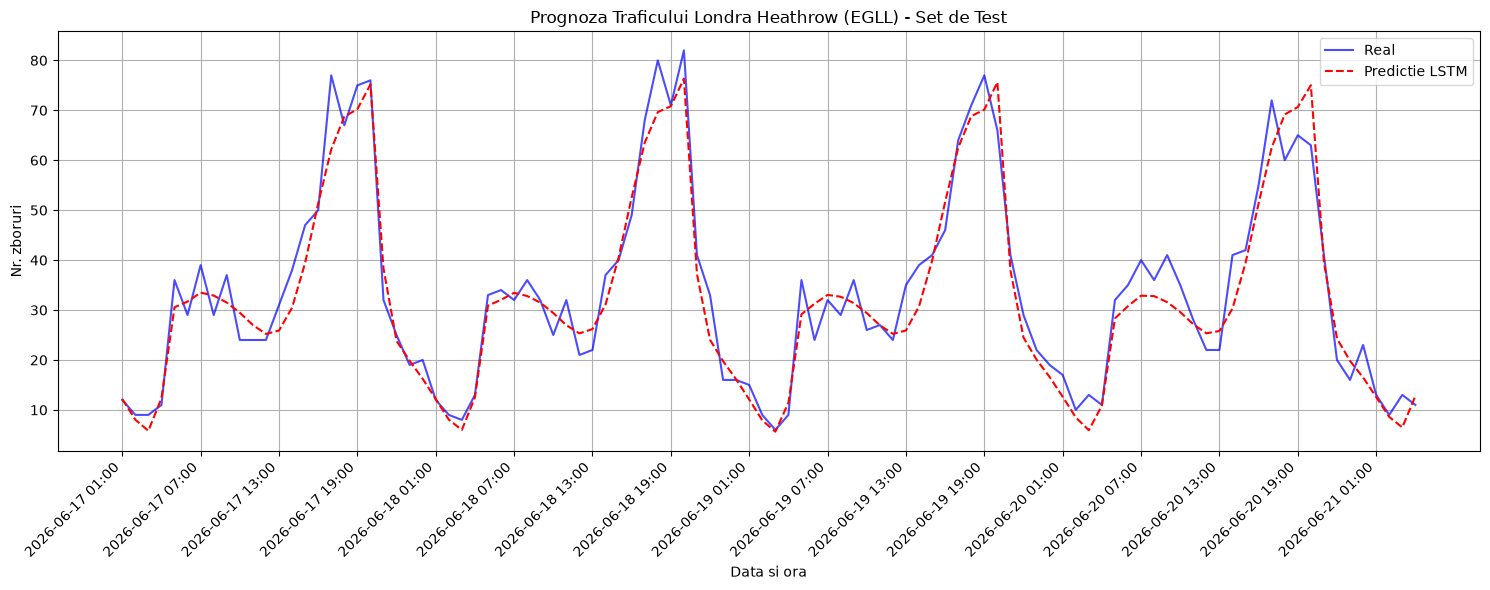

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions_scaled = model.predict(X_test)

def inverse_scale(predictions, y, features_len):
    placeholder = np.zeros((len(predictions), features_len))
    placeholder[:, 0] = predictions.flatten()
    return scaler.inverse_transform(placeholder)[:, 0]

predictions_real = inverse_scale(predictions_scaled, y_test, len(features))
y_test_real = inverse_scale(y_test.reshape(-1, 1), y_test, len(features))

# "data ora:00"
n_points = 100
axis_labels = [f"{row.date} {int(row.arrival_hour):02d}:00" for row in test_labels.iloc[:n_points].itertuples()]

plt.figure(figsize=(15, 6))
plt.plot(y_test_real[:n_points], label='Real', color='blue', alpha=0.7)
plt.plot(predictions_real[:n_points], label='Predictie LSTM', color='red', linestyle='--')
plt.title('Prognoza Traficului Londra Heathrow (EGLL) - Set de Test')
plt.xlabel('Data si ora')
plt.ylabel('Nr. zboruri')

# o eticheta la fiecare 6 puncte, ca sa nu se suprapuna
step = 6
plt.xticks(ticks=range(0, n_points, step), labels=axis_labels[::step], rotation=45, ha='right')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test_real, predictions_real)
rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
r2   = r2_score(y_test_real, predictions_real)

print(f'=== Rezultate LSTM ===')
print(f'MAE:  {mae:.2f} zboruri/ora')
print(f'RMSE: {rmse:.2f} zboruri/ora')
print(f'R2:   {r2:.2f}')
print('--------------------------------------------')

df_results = pd.DataFrame({
    'Data': test_labels['date'].iloc[-10:].values,
    'Ora': test_labels['arrival_hour'].iloc[-10:].values,
    'Real': y_test_real[-10:],
    'Predictie': predictions_real[-10:],
    'Eroare': np.abs(y_test_real[-10:] - predictions_real[-10:])
})
print('\nPredictii comparate (ultimele 10 - cele mai recente):')
print(df_results)

=== Rezultate LSTM ===
MAE:  6.19 zboruri/ora
RMSE: 9.23 zboruri/ora
R2:   0.81
--------------------------------------------

Predictii comparate (ultimele 10 - cele mai recente):
         Data  Ora  Real  Predictie     Eroare
0  2026-07-05    9   2.0  14.449036  12.449036
1  2026-07-05   10   3.0  27.505524  24.505524
2  2026-07-05   12   1.0  30.518558  29.518558
3  2026-07-05   13   4.0  32.406510  28.406510
4  2026-07-05   14   1.0  32.400555  31.400555
5  2026-07-05   16   1.0  32.746654  31.746654
6  2026-07-05   19   1.0  34.749439  33.749439
7  2026-07-05   20   4.0  38.725338  34.725338
8  2026-07-05   21  17.0  43.715241  26.715241
9  2026-07-05   22   3.0  49.083828  46.083828


### 6.8 Importanța feature-urilor pentru LSTM

Spre deosebire de RandomForest, LSTM nu oferă importanța feature-urilor direct. Folosim **permutation importance**: permutăm aleator valorile unui feature și măsurăm cât crește eroarea - un feature important va cauza o creștere mare a erorii când este perturbat.

In [19]:
def get_feature_importance(model, X_test, y_test, feature_names):
    baseline_pred = model.predict(X_test, verbose=0).flatten()
    baseline_error = mean_squared_error(y_test, baseline_pred)
    importances = []
    for i in range(X_test.shape[2]):
        X_permuted = X_test.copy()
        np.random.shuffle(X_permuted[:, :, i])
        permuted_pred = model.predict(X_permuted, verbose=0).flatten()
        permuted_error = mean_squared_error(y_test, permuted_pred)
        importances.append(permuted_error - baseline_error)
    return np.array(importances)

importances = get_feature_importance(model, X_test, y_test, features)
importances = np.maximum(importances, 0)
importances_percent = (importances / np.sum(importances)) * 100

df_importance = pd.DataFrame({
    'Feature': features,
    'Importanta (%)': importances_percent
}).sort_values(by='Importanta (%)', ascending=False)

print('=== Importanta Feature-urilor (Permutation Importance) ===')
print(df_importance.to_string(index=False, formatters={'Importanta (%)': '{:.2f}%'.format}))

=== Importanta Feature-urilor (Permutation Importance) ===
           Feature Importanta (%)
          hour_sin         35.03%
       media_7zile         34.47%
          hour_cos         13.20%
 flights_yesterday          8.74%
     flights_count          8.08%
       nr_companii          0.49%
volatilitate_7zile          0.00%


---
### Observații

1. **RandomForest** obține un scor bun (R² ≈ 0.84), apropiat de cel al **LSTM** (R² ≈ 0.81-0.83) — diferența dintre cele două metode este mică, ambele exploatând eficient feature-uri de tip lag (`media_7zile`, `flights_yesterday`) care captează pattern-urile repetitive ale traficului aerian.
2. **LSTM** rămâne util pentru contextul secvențial complet (ex. detectarea tendințelor de creștere/scădere pe parcursul zilei)
3. **KMeans** identifică corect că LROP este un aeroport regional cu volum semnificativ mai mic față de hub-urile vest-europene (EGLL, LFPG, EDDF, EHAM), iar corelația predicție-realitate a RandomForest confirmă acest tipar: LROP are cea mai slabă corelație (~0.83), în timp ce EGLL, cel mai mare hub, are cea mai bună (~0.92).
4. Feature-ul `volatilitate_7zile` a avut, în mod neașteptat, importanță aproape nulă atât pentru RandomForest cât și pentru LSTM — traficul, deși variază de la o zi la alta, nu pare să aibă o componentă de "impredictibilitate" separabilă de nivelul mediu istoric al fiecărei ore, semnal deja captat mai eficient de `media_7zile` și `hour_sin`/`hour_cos`.

In [ ]:
spark.stop()
print('SparkSession oprit. Notebook 2 finalizat!')